# Burst Rate vs KL Regularization

Compare two approaches to controlling forgetting during finetuning:
1. **Burst rate**: mix bg data into FT batches (implicit constraint)
2. **KL penalty**: train on 100% burst but penalize divergence from pretrained model (explicit constraint)

Analogy: burst_frac acts like a soft β in KL-regularized training.
- burst_frac=1.0 ≈ β=0 (no constraint)
- burst_frac→0 ≈ β→∞ (fully constrained)

In [1]:
import sys, os, importlib
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")

import simple.model, simple.data, simple.pretrain, simple.finetune, simple.forget, simple.interp, simple.report
for name in ["simple.model", "simple.data", "simple.pretrain", "simple.finetune",
             "simple.forget", "simple.interp", "simple.report"]:
    importlib.reload(sys.modules[name])

from simple import make_data, pretrain, forget, report
from simple.finetune import finetune, finetune_kl
from simple.forget import forget as forget_fn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

OUT = "data/burst_vs_kl"
SEED = 42

## 1. Data & Pretrain

Other tasks: 64, Burst tasks: 64


Pretrain: 0it [00:00, ?it/s]


Converged at step 875 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=1.0000, final loss_other=0.5842


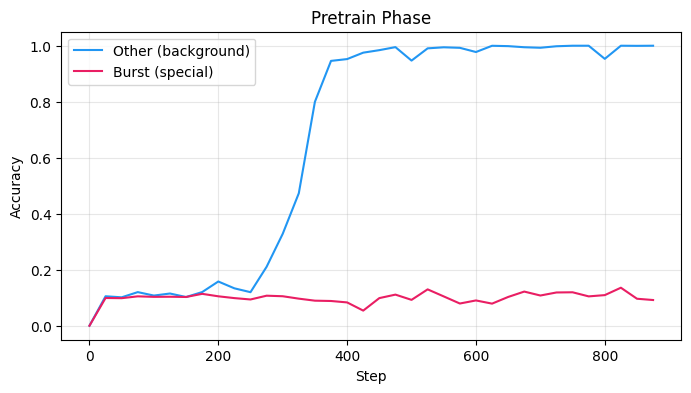

Checkpoint: data/burst_vs_kl/pretrain/pretrain_ckpt.pt


In [2]:
data = make_data(depth=3, burst_pos=3, n_a=4, n_burst=4, seed=SEED)
print(f"Other tasks: {data['task_info']['n_other_tasks']}, Burst tasks: {data['task_info']['n_burst_tasks']}")

pt = pretrain(data, f"{OUT}/pretrain", seed=SEED)
report.plot_pretrain(pt)
plt.show()
print(f"Checkpoint: {pt['ckpt_path']}")

## 2. Configuration

In [ ]:
FT_STEPS = 1500
FG_STEPS = 800
LR = 1e-4
FG_LR = 1e-4

# Burst rate sweep
FRACS = [1.0, 0.9, 0.7, 0.5, 0.3]

# KL beta sweep (higher β = more constrained ≈ lower burst frac)
KL_BETAS = [1, 0.01, 0.001, 0.0001, 0.00001, 0]

## 3. Burst Rate Sweep (baseline)

In [4]:
import torch.multiprocessing as mp
from simple.finetune import _finetune_worker
from simple.forget import _forget_worker

ctx = mp.get_context("spawn")

# ── Burst rate FT (parallel) ──
burst_ft_jobs = [dict(data=data, pretrain_ckpt=pt["ckpt_path"],
                      out_dir=f"{OUT}/finetune_burst",
                      burst_frac=frac, steps=FT_STEPS, lr=LR,
                      seed=SEED, quiet=True)
                 for frac in FRACS]

print(f"Running {len(burst_ft_jobs)} burst FT jobs in parallel...")
with ctx.Pool(len(burst_ft_jobs)) as pool:
    ft_burst = pool.map(_finetune_worker, burst_ft_jobs)
for r in ft_burst:
    print(f"  {r['tag']}: peak={r['peak_burst']:.3f}")

# ── Burst rate Forget (parallel) ──
burst_fg_jobs = [dict(data=data, finetune_ckpt=ft_r["ckpt_path"],
                      pretrain_ckpt=pt["ckpt_path"],
                      out_dir=f"{OUT}/forget_burst",
                      steps=FG_STEPS, lr=FG_LR,
                      tag=ft_r["tag"], seed=SEED, quiet=True)
                 for ft_r in ft_burst]

print(f"Running {len(burst_fg_jobs)} burst forget jobs in parallel...")
with ctx.Pool(len(burst_fg_jobs)) as pool:
    fg_burst = pool.map(_forget_worker, burst_fg_jobs)
for r in fg_burst:
    print(f"  {r['tag']}: drop={r['dropoff_pct']:.1f}%")

Running 5 burst FT jobs in parallel...
  burst_100: peak=1.000
  burst_90: peak=1.000
  burst_70: peak=1.000
  burst_50: peak=1.000
  burst_30: peak=0.984
Running 5 burst forget jobs in parallel...
  burst_100: drop=71.4%
  burst_90: drop=56.4%
  burst_70: drop=50.8%
  burst_50: drop=23.2%
  burst_30: drop=21.7%


## 4. KL Regularization Sweep

In [5]:
from simple.finetune import _finetune_kl_worker

# ── KL FT (parallel) ──
kl_ft_jobs = [dict(data=data, pretrain_ckpt=pt["ckpt_path"],
                   out_dir=f"{OUT}/finetune_kl",
                   kl_beta=beta, steps=FT_STEPS, lr=LR,
                   seed=SEED, quiet=True)
              for beta in KL_BETAS]

print(f"Running {len(kl_ft_jobs)} KL FT jobs in parallel...")
with ctx.Pool(len(kl_ft_jobs)) as pool:
    ft_kl = pool.map(_finetune_kl_worker, kl_ft_jobs)
for r in ft_kl:
    print(f"  {r['tag']}: peak={r['peak_burst']:.3f}")

# ── KL Forget (parallel) ──
kl_fg_jobs = [dict(data=data, finetune_ckpt=ft_r["ckpt_path"],
                   pretrain_ckpt=pt["ckpt_path"],
                   out_dir=f"{OUT}/forget_kl",
                   steps=FG_STEPS, lr=FG_LR,
                   tag=ft_r["tag"], seed=SEED, quiet=True)
              for ft_r in ft_kl]

print(f"Running {len(kl_fg_jobs)} KL forget jobs in parallel...")
with ctx.Pool(len(kl_fg_jobs)) as pool:
    fg_kl = pool.map(_forget_worker, kl_fg_jobs)
for r in fg_kl:
    print(f"  {r['tag']}: drop={r['dropoff_pct']:.1f}%")

Running 3 KL FT jobs in parallel...
  kl_1e-02: peak=0.380
  kl_0.001: peak=1.000
  kl_0.0001: peak=1.000
Running 3 KL forget jobs in parallel...
  kl_1e-02: drop=29.4%
  kl_0.001: drop=74.5%
  kl_0.0001: drop=72.0%


## 5. Save results

In [6]:
import pickle
with open(f"{OUT}/results.pkl", "wb") as f:
    pickle.dump({"ft_burst": ft_burst, "fg_burst": fg_burst,
                 "ft_kl": ft_kl, "fg_kl": fg_kl,
                 "FRACS": FRACS, "KL_BETAS": KL_BETAS}, f)
print("Saved.")

# Uncomment to load:
# with open(f"{OUT}/results.pkl", "rb") as f:
#     saved = pickle.load(f)
# ft_burst, fg_burst = saved["ft_burst"], saved["fg_burst"]
# ft_kl, fg_kl = saved["ft_kl"], saved["fg_kl"]

Saved.


## 6. Comparison Plots

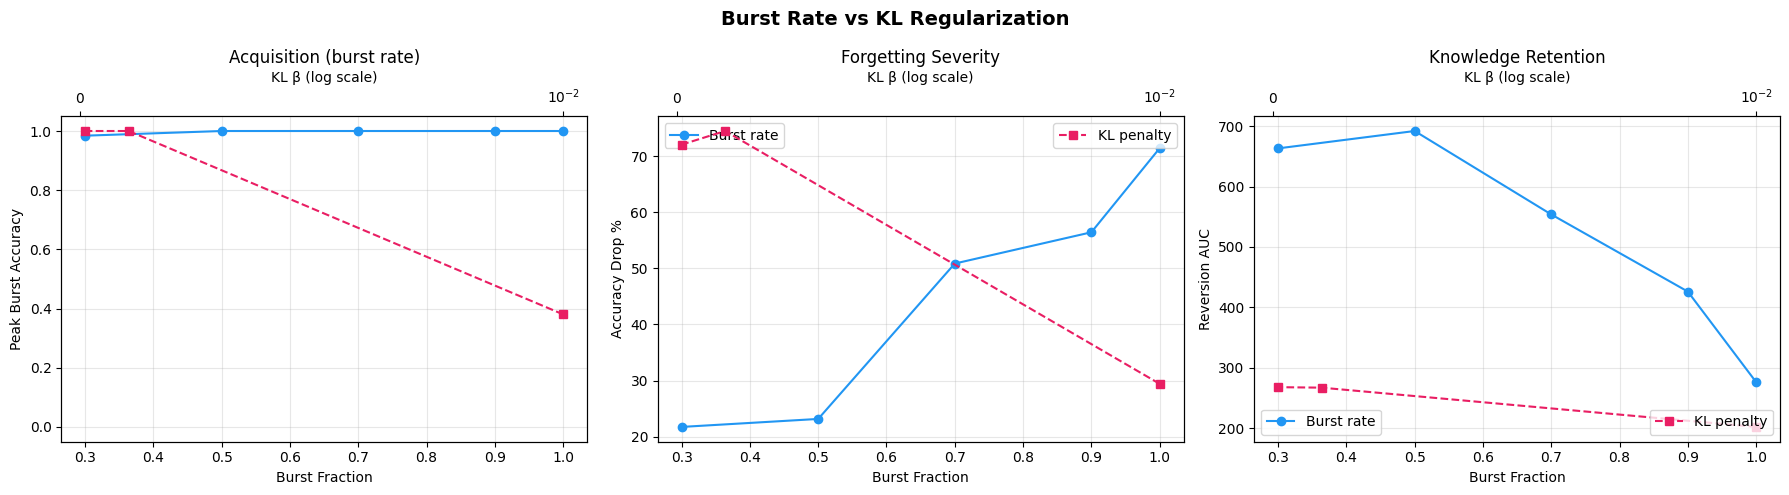

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Acquisition: peak burst accuracy ──
ax = axes[0]
ax.plot(FRACS, [r["peak_burst"] for r in ft_burst], "o-", color="#2196F3", label="Burst rate")
ax.set_xlabel("Burst Fraction"); ax.set_ylabel("Peak Burst Accuracy")
ax.set_title("Acquisition (burst rate)"); ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

ax2 = ax.twiny()
ax2.plot(KL_BETAS, [r["peak_burst"] for r in ft_kl], "s--", color="#E91E63", label="KL penalty")
ax2.set_xlabel("KL β (log scale)")
ax2.set_xscale("symlog", linthresh=0.01)

# ── Forgetting: drop % ──
ax = axes[1]
ax.plot(FRACS, [r["dropoff_pct"] for r in fg_burst], "o-", color="#2196F3", label="Burst rate")
ax.set_xlabel("Burst Fraction"); ax.set_ylabel("Accuracy Drop %")
ax.set_title("Forgetting Severity"); ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

ax2 = ax.twiny()
ax2.plot(KL_BETAS, [r["dropoff_pct"] for r in fg_kl], "s--", color="#E91E63", label="KL penalty")
ax2.set_xlabel("KL β (log scale)")
ax2.set_xscale("symlog", linthresh=0.01)
ax2.legend(loc="upper right")

# ── Retention: reversion AUC ──
ax = axes[2]
ax.plot(FRACS, [r["reversion_auc"] for r in fg_burst], "o-", color="#2196F3", label="Burst rate")
ax.set_xlabel("Burst Fraction"); ax.set_ylabel("Reversion AUC")
ax.set_title("Knowledge Retention"); ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")

ax2 = ax.twiny()
ax2.plot(KL_BETAS, [r["reversion_auc"] for r in fg_kl], "s--", color="#E91E63", label="KL penalty")
ax2.set_xlabel("KL β (log scale)")
ax2.set_xscale("symlog", linthresh=0.01)
ax2.legend(loc="lower right")

fig.suptitle("Burst Rate vs KL Regularization", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

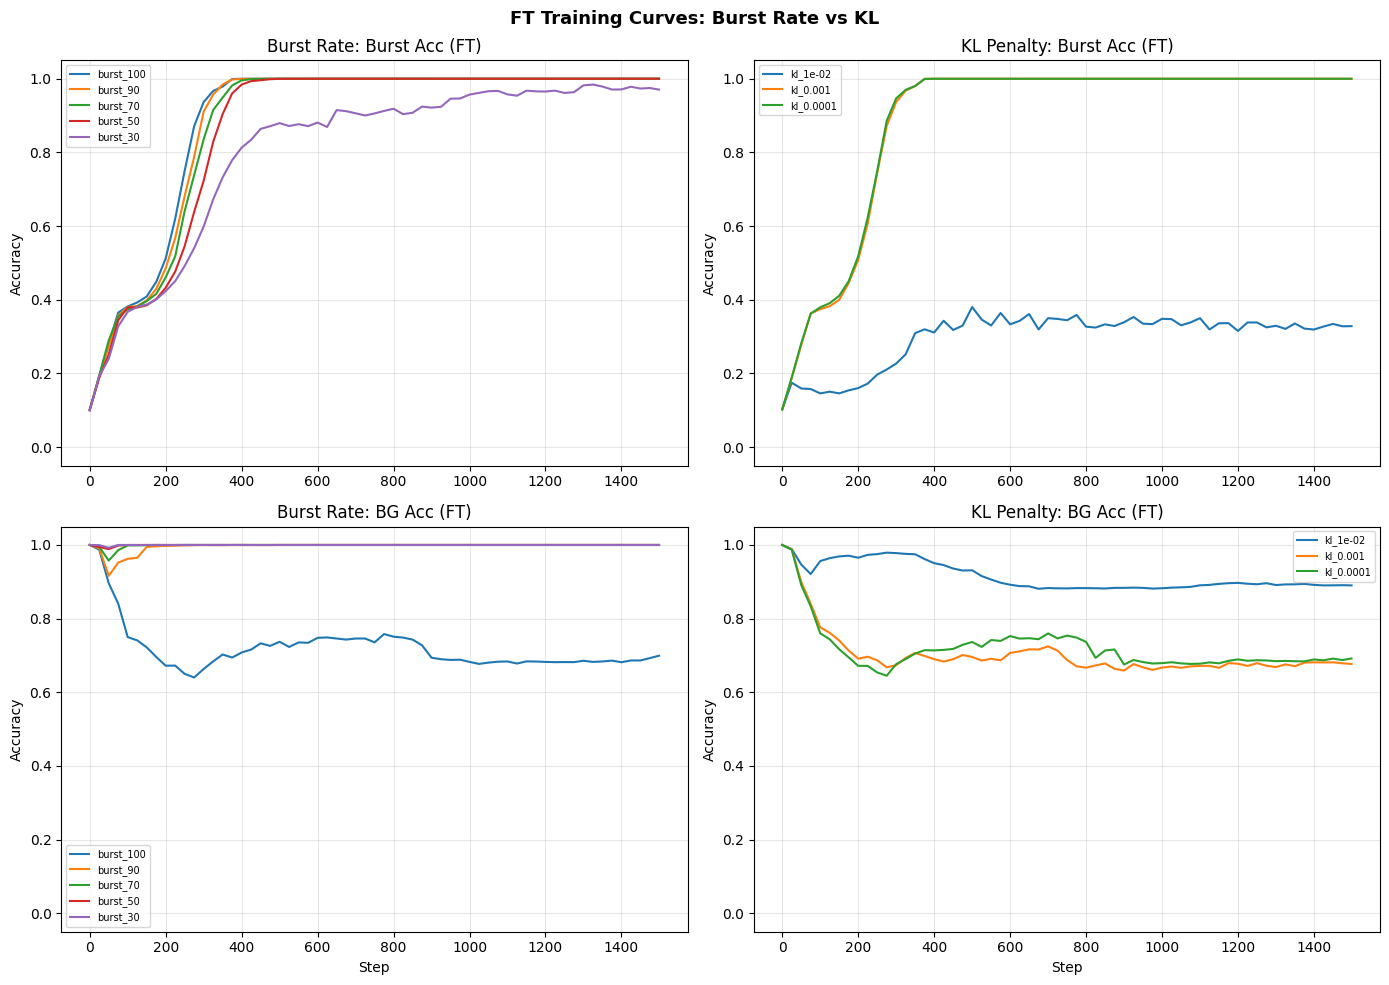

In [8]:
# Training curves side by side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Burst accuracy during FT
ax = axes[0, 0]
for r in ft_burst:
    ax.plot(r["log"]["step"], r["log"]["acc_burst"], label=r["tag"], linewidth=1.5)
ax.set_title("Burst Rate: Burst Acc (FT)"); ax.set_ylabel("Accuracy")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.05)

ax = axes[0, 1]
for r in ft_kl:
    ax.plot(r["log"]["step"], r["log"]["acc_burst"], label=r["tag"], linewidth=1.5)
ax.set_title("KL Penalty: Burst Acc (FT)"); ax.set_ylabel("Accuracy")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.05)

# BG accuracy during FT
ax = axes[1, 0]
for r in ft_burst:
    ax.plot(r["log"]["step"], r["log"]["acc_other"], label=r["tag"], linewidth=1.5)
ax.set_title("Burst Rate: BG Acc (FT)"); ax.set_ylabel("Accuracy"); ax.set_xlabel("Step")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.05)

ax = axes[1, 1]
for r in ft_kl:
    ax.plot(r["log"]["step"], r["log"]["acc_other"], label=r["tag"], linewidth=1.5)
ax.set_title("KL Penalty: BG Acc (FT)"); ax.set_ylabel("Accuracy"); ax.set_xlabel("Step")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.05)

fig.suptitle("FT Training Curves: Burst Rate vs KL", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

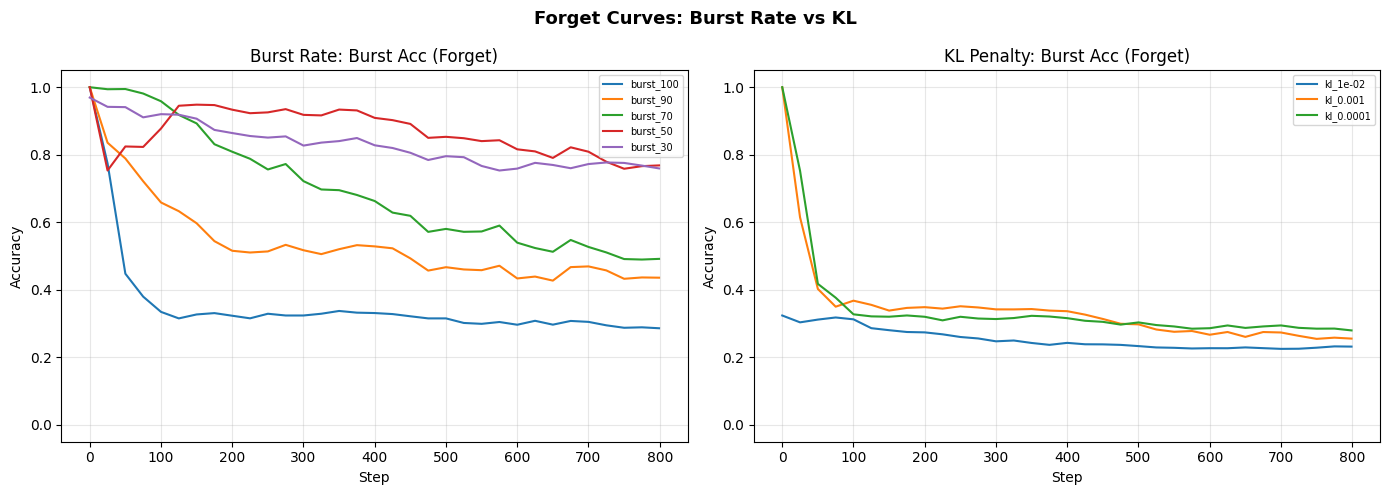

In [9]:
# Forget curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for r in fg_burst:
    ax.plot(r["log"]["step"], r["log"]["acc_burst"], label=r["tag"], linewidth=1.5)
ax.set_title("Burst Rate: Burst Acc (Forget)"); ax.set_ylabel("Accuracy"); ax.set_xlabel("Step")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.05)

ax = axes[1]
for r in fg_kl:
    ax.plot(r["log"]["step"], r["log"]["acc_burst"], label=r["tag"], linewidth=1.5)
ax.set_title("KL Penalty: Burst Acc (Forget)"); ax.set_ylabel("Accuracy"); ax.set_xlabel("Step")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.05)

fig.suptitle("Forget Curves: Burst Rate vs KL", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

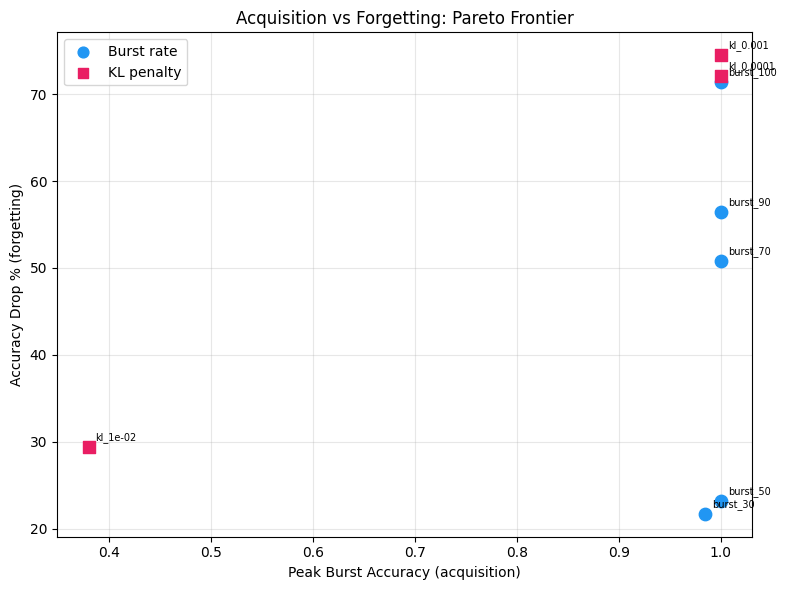

In [10]:
# Pareto frontier: peak burst acc vs forgetting severity
fig, ax = plt.subplots(figsize=(8, 6))

for r_ft, r_fg in zip(ft_burst, fg_burst):
    ax.scatter(r_ft["peak_burst"], r_fg["dropoff_pct"], c="#2196F3", s=80, zorder=3)
    ax.annotate(r_ft["tag"], (r_ft["peak_burst"], r_fg["dropoff_pct"]),
                fontsize=7, textcoords="offset points", xytext=(5, 5))

for r_ft, r_fg in zip(ft_kl, fg_kl):
    ax.scatter(r_ft["peak_burst"], r_fg["dropoff_pct"], c="#E91E63", s=80, zorder=3, marker="s")
    ax.annotate(r_ft["tag"], (r_ft["peak_burst"], r_fg["dropoff_pct"]),
                fontsize=7, textcoords="offset points", xytext=(5, 5))

ax.scatter([], [], c="#2196F3", label="Burst rate", s=60)
ax.scatter([], [], c="#E91E63", marker="s", label="KL penalty", s=60)
ax.set_xlabel("Peak Burst Accuracy (acquisition)"); ax.set_ylabel("Accuracy Drop % (forgetting)")
ax.set_title("Acquisition vs Forgetting: Pareto Frontier")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

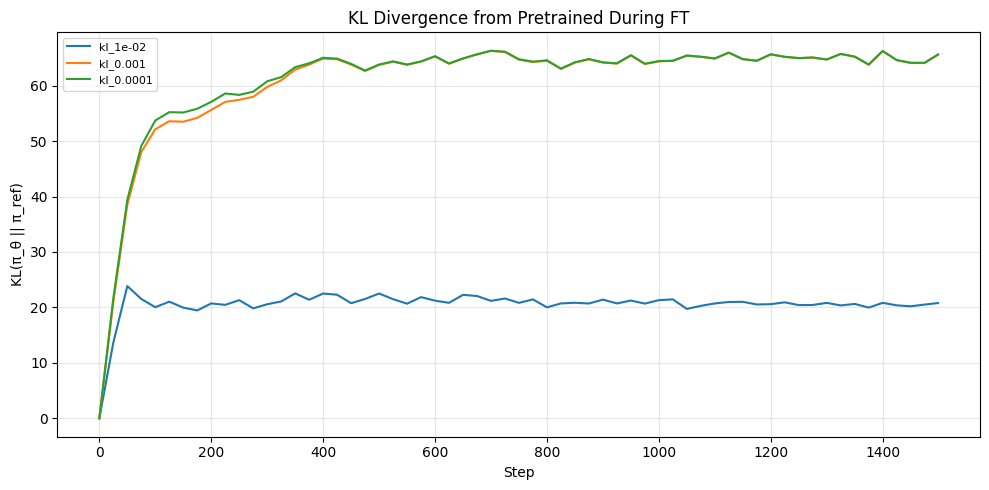

In [11]:
# KL divergence during FT for KL runs
fig, ax = plt.subplots(figsize=(10, 5))
for r in ft_kl:
    if "kl" in r["log"]:
        ax.plot(r["log"]["step"], r["log"]["kl"], label=r["tag"], linewidth=1.5)
ax.set_xlabel("Step"); ax.set_ylabel("KL(π_θ || π_ref)")
ax.set_title("KL Divergence from Pretrained During FT")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

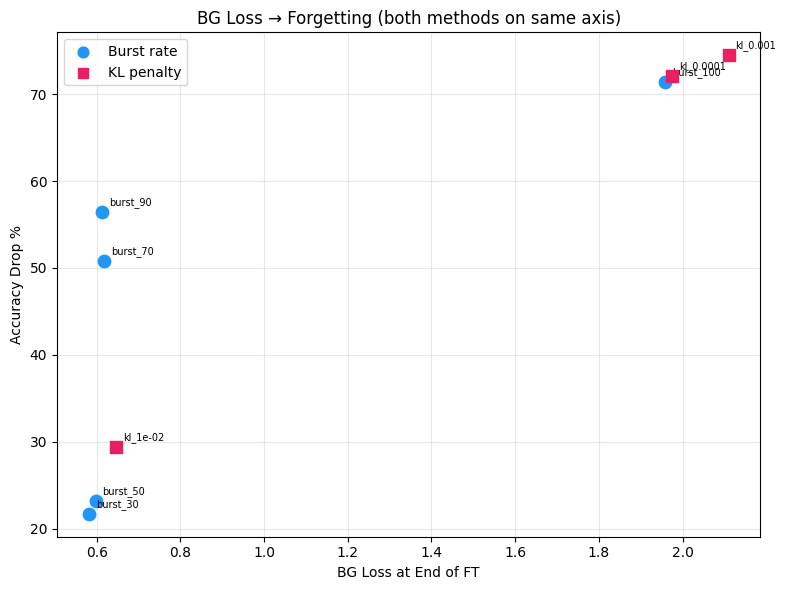

In [12]:
# BG loss at end of FT vs forgetting — both methods on same plot
fig, ax = plt.subplots(figsize=(8, 6))

for r_ft, r_fg in zip(ft_burst, fg_burst):
    bg_loss = r_ft["log"]["loss_other"][-1]
    ax.scatter(bg_loss, r_fg["dropoff_pct"], c="#2196F3", s=80, zorder=3)
    ax.annotate(r_ft["tag"], (bg_loss, r_fg["dropoff_pct"]),
                fontsize=7, textcoords="offset points", xytext=(5, 5))

for r_ft, r_fg in zip(ft_kl, fg_kl):
    bg_loss = r_ft["log"]["loss_other"][-1]
    ax.scatter(bg_loss, r_fg["dropoff_pct"], c="#E91E63", s=80, zorder=3, marker="s")
    ax.annotate(r_ft["tag"], (bg_loss, r_fg["dropoff_pct"]),
                fontsize=7, textcoords="offset points", xytext=(5, 5))

ax.scatter([], [], c="#2196F3", label="Burst rate", s=60)
ax.scatter([], [], c="#E91E63", marker="s", label="KL penalty", s=60)
ax.set_xlabel("BG Loss at End of FT"); ax.set_ylabel("Accuracy Drop %")
ax.set_title("BG Loss → Forgetting (both methods on same axis)")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()